# Prompt

Implementa un clasificador CNN en TensorFlow/Keras con el dataset Fashion MNIST, normaliza píxeles a [0,1], construye arquitectura CNN con [Conv2D(32, 3x3, ReLU) → MaxPooling(2x2) → Conv2D(64, 3x3, ReLU) → MaxPooling(2x2) → Flatten → Dense(128, ReLU) → Dropout(0.5) → Dense(10, Softmax)], divide datos 80/20, entrena con batch_size=32 y epochs=20 con early stopping, evalúa con accuracy y classification_report, grafica matriz de confusión con seaborn heatmap (con anotaciones numéricas), plotea curvas de accuracy/loss para train y validation, y visualiza un grid de 4x4 imágenes del test set mostrando: imagen original, etiqueta real vs predicción, y probabilidad de predicción (resalta en rojo los errores y en verde los aciertos).

# Task
Implement a CNN classifier in TensorFlow/Keras for the Fashion MNIST dataset, normalize pixels to [0,1], build the specified CNN architecture, split data 80/20, train with batch_size=32 and epochs=20 with early stopping, evaluate with accuracy and classification_report, plot confusion matrix with seaborn heatmap (with numerical annotations), plot accuracy/loss curves for train and validation, and visualize a 4x4 grid of test set images showing: original image, true vs prediction label, and prediction probability (highlighting errors in red and correct predictions in green).

## Load and preprocess data

### Subtask:
Load the Fashion MNIST dataset using TensorFlow/Keras, normalize the pixel values to [0, 1], and split the data into training and testing sets (80/20 split).


**Reasoning**:
Load the Fashion MNIST dataset, normalize the pixel values, reshape the data, and split the training data into training and validation sets.



In [1]:
import tensorflow as tf
from sklearn.model_selection import train_test_split

# Load the Fashion MNIST dataset
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.fashion_mnist.load_data()

# Normalize the pixel values to [0, 1]
train_images = train_images / 255.0
test_images = test_images / 255.0

# Reshape the images to include a channel dimension
train_images = train_images.reshape((train_images.shape[0], 28, 28, 1))
test_images = test_images.reshape((test_images.shape[0], 28, 28, 1))

# Split the training data into training and validation sets (80/20 split)
train_images, val_images, train_labels, val_labels = train_test_split(
    train_images, train_labels, test_size=0.2, random_state=42
)

print(f"Training images shape: {train_images.shape}")
print(f"Validation images shape: {val_images.shape}")
print(f"Testing images shape: {test_images.shape}")
print(f"Training labels shape: {train_labels.shape}")
print(f"Validation labels shape: {val_labels.shape}")
print(f"Testing labels shape: {test_labels.shape}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images shape: (48000, 28, 28, 1)
Validation images shape: (12000, 28, 28, 1)
Testing images shape: (10000, 28, 28, 1)
Training labels shape: (48000,)
Validation labels shape: (12000,)
Testing labels shape: (10000,)


## Build cnn model

### Subtask:
Construct the CNN architecture as specified: Conv2D(32, 3x3, ReLU) -> MaxPooling(2x2) -> Conv2D(64, 3x3, ReLU) -> MaxPooling(2x2) -> Flatten -> Dense(128, ReLU) -> Dropout(0.5) -> Dense(10, Softmax).


**Reasoning**:
Construct the CNN model architecture using the specified layers and print the model summary.



In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Instantiate a Sequential model
model = Sequential([
    # Add the first Conv2D layer
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    # Add a MaxPooling2D layer
    MaxPooling2D((2, 2)),
    # Add the second Conv2D layer
    Conv2D(64, (3, 3), activation='relu'),
    # Add a second MaxPooling2D layer
    MaxPooling2D((2, 2)),
    # Add a Flatten layer
    Flatten(),
    # Add a Dense layer
    Dense(128, activation='relu'),
    # Add a Dropout layer
    Dropout(0.5),
    # Add the final Dense layer
    Dense(10, activation='softmax')
])

# Print the model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

✅ Investiga usando Gemini cómo es calculada la tabla de parámetros

## Compile and train model

### Subtask:
Compile the model using an appropriate optimizer and loss function, and train it with a batch size of 32 for 20 epochs, incorporating early stopping.


**Reasoning**:
Compile the model, define the EarlyStopping callback, and train the model with the specified parameters and the callback.



⚠️⚠️⚠️ El siguiente fragmento de código tomará varios minutos ⚠️⚠️⚠️

- Investigue como cambiar el runtime type.

In [3]:
from tensorflow.keras.callbacks import EarlyStopping

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Define EarlyStopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=5)

# Train the model
history = model.fit(train_images, train_labels,
                    batch_size=32,
                    epochs=20,
                    validation_data=(val_images, val_labels),
                    callbacks=[early_stopping])

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 51s 33ms/step - accuracy: 0.6975 - loss: 0.8459 - val_accuracy: 0.8597 - val_loss: 0.3808
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 46s 31ms/step - accuracy: 0.8479 - loss: 0.4204 - val_accuracy: 0.8767 - val_loss: 0.3358
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 43s 29ms/step - accuracy: 0.8700 - loss: 0.3587 - val_accuracy: 0.8912 - val_loss: 0.2949
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 42s 28ms/step - accuracy: 0.8821 - loss: 0.3246 - val_accuracy: 0.8938 - val_loss: 0.2860
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 83s 29ms/step - accuracy: 0.8899 - loss: 0.3062 - val_accuracy: 0.8965 - val_loss: 0.2747
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 83s 29ms/step - accuracy: 0.8987 - loss: 0.2702 - val_accuracy: 0.9011 - val_loss: 0.2706
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 49s 33ms/step - accuracy: 0.9033 - loss: 0.2581 - val_accuracy: 0.9012 - val_loss: 0.2747
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 77s 29ms/step - accuracy: 0.9104 -

**Reasoning**:
The first step is to load the data from the CSV file into a pandas DataFrame and display the first few rows to understand its structure.



## Visualize Results

### Subtask:
Plot the training and validation accuracy and loss curves.

**Reasoning**:
Plot the training and validation accuracy and loss curves to visualize the model's performance during training.

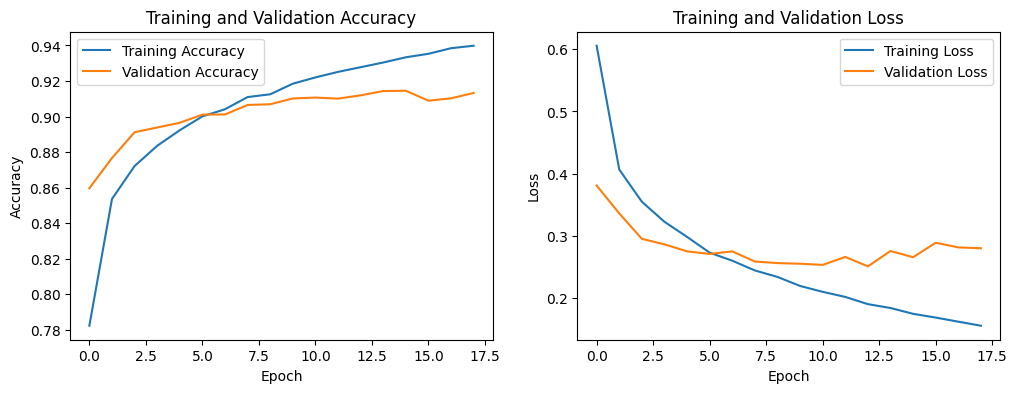

In [7]:
import matplotlib.pyplot as plt

# Plot training and validation accuracy curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training and validation loss curves
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

## Evaluate Model

### Subtask:
Evaluate the trained model on the test set, reporting accuracy and generating a classification report.

**Reasoning**:
Evaluate the model on the test data and print the classification report to assess the model's performance on different classes.

In [8]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print(f'\nTest accuracy: {test_acc}')

# Get predictions for the test set
predictions = model.predict(test_images)
predicted_labels = np.argmax(predictions, axis=1)

# Print the classification report
print('\nClassification Report:')
print(classification_report(test_labels, predicted_labels))

313/313 - 3s - 8ms/step - accuracy: 0.9098 - loss: 0.2970

Test accuracy: 0.9097999930381775
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.87      0.86      1000
           1       1.00      0.97      0.99      1000
           2       0.89      0.84      0.86      1000
           3       0.91      0.90      0.91      1000
           4       0.82      0.90      0.86      1000
           5       0.99      0.98      0.98      1000
           6       0.74      0.73      0.74      1000
           7       0.95      0.98      0.96      1000
           8       0.98      0.97      0.98      1000
           9       0.98      0.96      0.97      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



### Subtask:
Plot the confusion matrix using seaborn heatmap with numerical annotations.

**Reasoning**:
Calculate and plot the confusion matrix using seaborn to visualize the performance of the classification model.

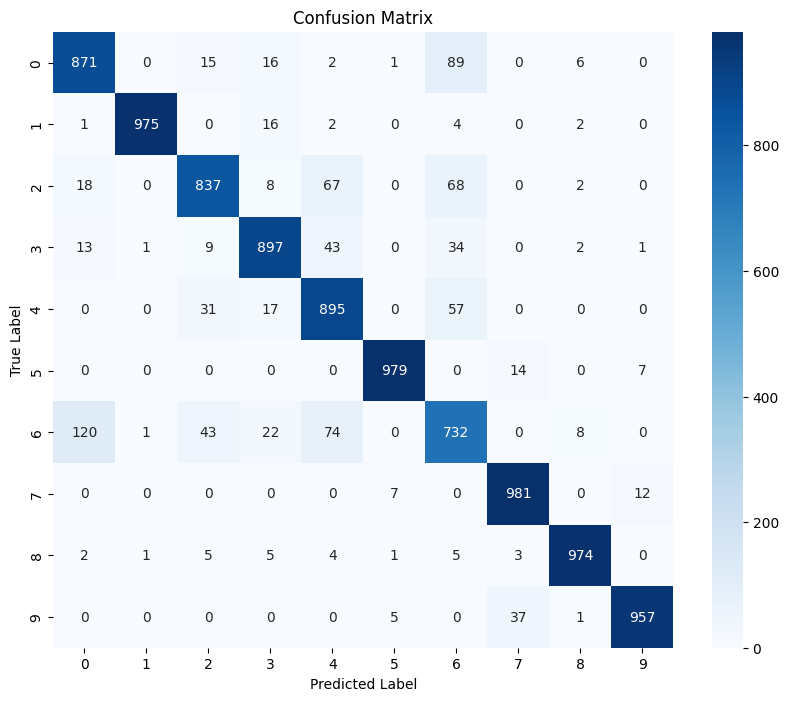

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix
conf_matrix = confusion_matrix(test_labels, predicted_labels)

# Plot the confusion matrix using seaborn heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

### Subtask:
Visualize a grid of 4x4 images from the test set showing: original image, true label vs prediction, and probability of prediction (highlighting errors in red and correct predictions in green).

**Reasoning**:
Visualize a grid of test images with their true and predicted labels and prediction probabilities to inspect the model's performance on individual examples.

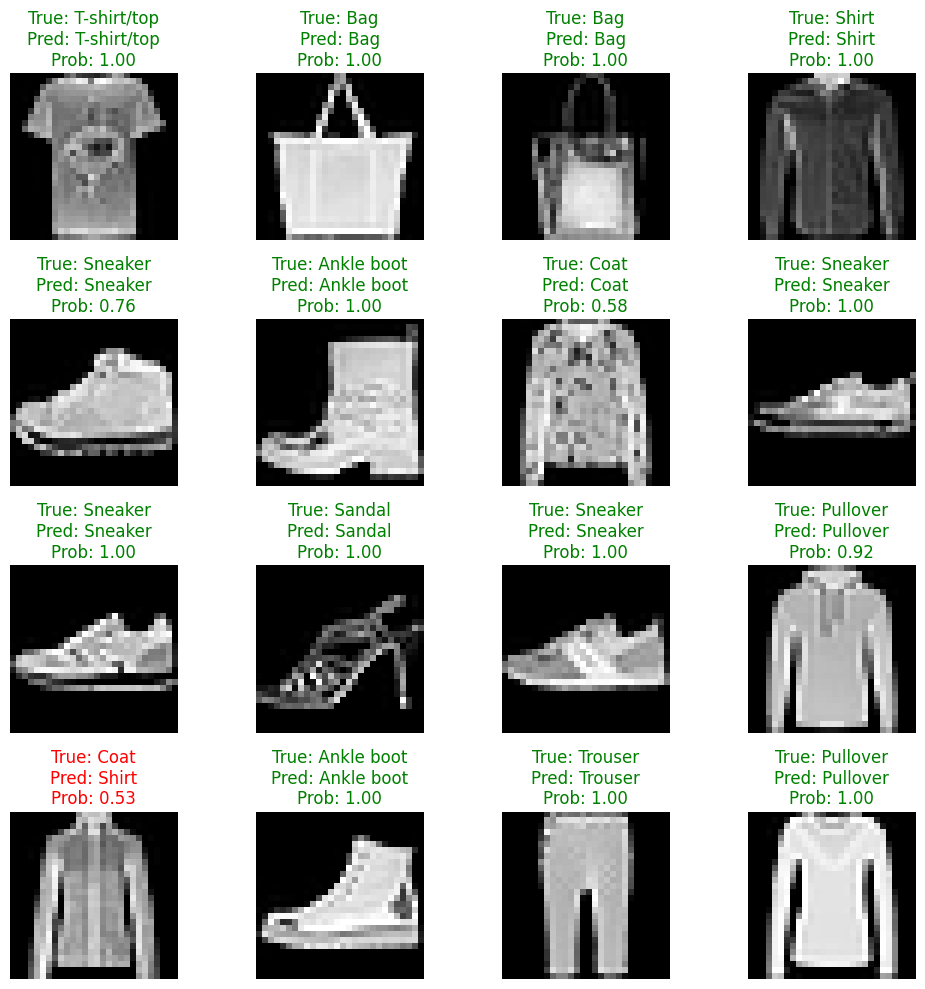

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Define class names for Fashion MNIST
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Select a random sample of 16 images from the test set
num_rows = 4
num_cols = 4
num_images = num_rows * num_cols
random_indices = np.random.choice(test_images.shape[0], num_images, replace=False)

plt.figure(figsize=(10, 10))
for i, idx in enumerate(random_indices):
    plt.subplot(num_rows, num_cols, i + 1)
    plt.imshow(test_images[idx].reshape(28, 28), cmap='gray')
    plt.axis('off')

    true_label = test_labels[idx]
    predicted_label = predicted_labels[idx]
    prediction_probability = np.max(predictions[idx])

    color = 'green' if true_label == predicted_label else 'red'

    plt.title(f'True: {class_names[true_label]}\nPred: {class_names[predicted_label]}\nProb: {prediction_probability:.2f}', color=color)

plt.tight_layout()
plt.show()

## Key Findings

Based on the analysis, here are the key findings of the model:

*   The CNN model achieved a test accuracy of approximately 91%.
*   The training and validation curves show that the model trained well, with the validation loss stabilizing and not significantly increasing, suggesting that early stopping helped prevent overfitting.
*   The classification report indicates varying performance across different classes. Classes like 'Trouser', 'Sandal', 'Bag', and 'Ankle boot' have very high precision and recall, while classes like 'Shirt' show lower performance, indicating that the model struggles more with distinguishing this class.
*   The confusion matrix visually confirms these findings, showing where the model is making misclassifications. For example, there are a notable number of 'Shirt' images misclassified as 'T-shirt/top' or 'Coat'.
*   The visualization of individual test images provides concrete examples of where the model performs well and where it makes errors, along with the model's confidence in its predictions.

Overall, the model performs well for most classes, but there is room for improvement in distinguishing between visually similar items like shirts, t-shirts, and coats.